# HNW & SWE Validation — dSnow (SnowToSwe, Python port)

Validates the **Winkler et al. 2021 Δ-Snow** model against the **Mag25** dataset.

**Model**: `SnowToSwe` (pure-Python port of the R `nixmass::swe.delta.snow` by M. Theurl),
run with the original Winkler 2021 default parameters.

**Workflow**
1. Load the multi-station NetCDF (`Mag25_all.nc`).
2. Run `SnowToSwe.convert_list(...)` on each station's HS series → `SWE_mod`.
3. Derive `HNW_mod` from day-to-day `SWE_mod` increments (negative melt diffs clipped to 0).
4. Validate **HNW** and **SWE** against observations, restricted to days with a valid `SWE_obs`
   (biweekly snow-course surveys — avoids inflating stats with unobserved days).
5. Cross-check the Python run against the R `nixmass` implementation on a single
   station/season (Adelboden 2016/17); CSV must first be generated by
   `adelboden_nixmass_single_season.R`.


In [1]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ── Project root ─────────────────────────────────────────────────────────────
base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)

# ── Paths ─────────────────────────────────────────────────────────────────────
Mag25_nc_file = "/Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"
save_dir      = base_dir / "HNW_validation/validation_plots"

# ── Local imports ─────────────────────────────────────────────────────────────
import HNW_validation.HNW_validation_helper as val_helper

sys.path.insert(0, str(base_dir / "snow_to_swe_master"))
from main import SnowToSwe

warnings.filterwarnings("ignore", category=FutureWarning, module=r"main")

# ── Run configuration ─────────────────────────────────────────────────────────
model_source  = "SnowToSwe"
calib_comment = "SnowToSwe_default_Winkler2021"
save_data     = False


snow_to_swe = SnowToSwe(
    # rho_max=399.068,
    # rho_null=99.5745,
    # c_ov=0.00053726,
    # k_ov=0.414444,
    # k=0.0263879,
    # tau=0.0230785,
    # eta_null=8770340
)


print(f"model_source  : {model_source}")
print(f"Mag25_nc_file : {Mag25_nc_file}")
print(f"calib_comment : {calib_comment}")

This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'
model_source  : SnowToSwe
Mag25_nc_file : /Users/jakobwerkgarner/code/mt_dsnow/calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc
calib_comment : SnowToSwe_default_Winkler2021


In [21]:
Mag25_data['SWE']

<xarray.DataArray 'SWE' (time: 2191, station: 41)> Size: 719kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(2191, 41))
Coordinates:
  * time     (time) datetime64[ns] 18kB 2016-09-01T06:00:00 ... 2022-08-31T06...
  * station  (station) <U17 3kB 'Adelboden' 'Gadmen' ... 'Samnaun' 'Zuoz'
Attributes:
    units:    mm

In [24]:
valid_count = int(Mag25_data['SWE'].notnull().sum().values)

print(f"Number of valid (non-NaN) values in SWE: {valid_count}")

Number of valid (non-NaN) values in SWE: 1157


In [2]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ── Load Mag25 multi-station NetCDF (FULL YEAR — do NOT pre-filter) ──────────
# Running SnowToSwe per-winter requires each call to end on a snow-free day.
# If we cut at Apr 30, stations with snow still on the ground that day crash
# SnowToSwe's internal loop. Using hydrological years Sep 1 -> Aug 31 lets
# the summer naturally bring HS to 0 at the boundaries.

Mag25_data = xr.open_dataset(Mag25_nc_file)
Mag25_data = Mag25_data.drop_sel(station="Weisfluh_Joch")

Mag25_data_with_SWE = Mag25_data.copy()
Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

times        = pd.to_datetime(Mag25_data["time"].values)
hyd_year     = np.where(times.month > 8, times.year, times.year - 1)   # ← fix typo
winter_years = np.unique(hyd_year)



# ── Per-(station × hydrological year) worker ─────────────────────────────────
def process_station_winter(station_name, winter_year,
                           time_idx, hs_values, snow_to_swe):
    """Run SnowToSwe on ONE station × ONE hydrological year (Sep–Aug)."""
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    try:
        hs = pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None
        # SnowToSwe preconditions: series must start at 0
        if hs.iloc[0] != 0:
            hs.iloc[0] = 0.0
        if hs.iloc[-1] != 0:
            hs.iloc[-1] = 0.0        # ← add this

        swe_list = snow_to_swe.convert_list(hs.tolist(),
                                            timestep=24, verbose=False)
        if swe_list is None:
            return None

        swe_arr = np.asarray(swe_list, dtype=float)
        assert swe_arr.shape[0] == len(hs)
        return (station_name, winter_year, time_idx, swe_arr)
    except Exception as e:
        return ("__ERROR__", station_name,
                f"winter {winter_year}/{winter_year + 1}: {e}")


# ── Build (station × winter) task list ───────────────────────────────────────
station_list = Mag25_data["station"].values
hs_by_stn    = {s: Mag25_data["HS"].sel(station=s).values for s in station_list}

tasks = []
for stn in station_list:
    hs_full = hs_by_stn[stn]
    for y in winter_years:
        mask     = hyd_year == y
        time_idx = times[mask].values
        hs_vals  = hs_full[mask]
        tasks.append((stn, int(y), time_idx, hs_vals))

n_jobs = -1
print(f"Running SnowToSwe on {len(station_list)} stations × "
      f"{len(winter_years)} hydrological years = {len(tasks)} tasks "
      f"(parallel, n_jobs={n_jobs})…")

results = []
with tqdm(total=len(tasks), desc="Station×Winter", unit="task") as pbar:
    for r in Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(process_station_winter)(stn, y, tidx, hsv, snow_to_swe)
        for (stn, y, tidx, hsv) in tasks
    ):
        results.append(r)
        pbar.update(1)


# ── Collect results back into SWE_mod ────────────────────────────────────────
errors      = []
ok_tasks    = 0
ok_stations = set()

for result in results:
    if result is None:
        continue
    if isinstance(result, tuple) and result and result[0] == "__ERROR__":
        errors.append((result[1], result[2]))
        continue

    station_name, wyr, time_idx, swe_arr = result
    Mag25_data_with_SWE["SWE_mod"].loc[
        dict(station=station_name, time=time_idx)
    ] = swe_arr
    ok_tasks += 1
    ok_stations.add(station_name)


# ── Observation counts per station ───────────────────────────────────────────
obs_counts_df = pd.DataFrame([
    {"station": s,
     "n_obs": int(Mag25_data["SWE"].sel(station=s).notnull().sum().item())}
    for s in station_list
])

print(f"\nDone. Tasks processed: {ok_tasks} / {len(tasks)}")
print(f"Stations with ≥1 successful winter: "
      f"{len(ok_stations)} / {len(station_list)}")
print(f"Hydrological years: {list(winter_years)} ({len(winter_years)} seasons)")
print(f"Total time steps (full year): {Mag25_data.sizes['time']}")

if errors:
    print(f"\nErrors on {len(errors)} (station, winter) pair(s):")
    for stn, msg in errors:
        print(f"  {stn}: {msg}")

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Running SnowToSwe on 40 stations × 6 hydrological years = 240 tasks (parallel, n_jobs=-1)…


Station×Winter: 100%|██████████| 240/240 [00:29<00:00,  8.25task/s]


Done. Tasks processed: 240 / 240
Stations with ≥1 successful winter: 40 / 40
Hydrological years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)] (6 seasons)
Total time steps (full year): 2191


In [3]:
# ── Derive HNW_mod from day-to-day SWE_mod increments ────────────────────────
# Negative diffs represent melt, not new snow, so clip them to 0.
# .reindex() restores the full time axis (diff drops the first timestep).

HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time").clip(min=0)
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

Mag25_data_with_SWE["HNW_mod"] = HNW_mod

# ── Build one long-format frame with both pairs (obs & mod) ─────────────────
all_df = (Mag25_data_with_SWE[["HNW", "HNW_mod", "SWE", "SWE_mod", "HS"]]
          .to_dataframe()
          .reset_index()
          .rename(columns={"HNW": "HNW_obs", "SWE": "SWE_obs"}))

# ── Keep only days with a valid observed SWE ────────────────────────────────
# Mag25 SWE is biweekly snow-course data (NaN on most days). Validating on the
# observed days only yields statistically meaningful RMSE / R², and puts the
# HNW and SWE comparisons onto the same subset of rows.

SWE_val = all_df[all_df["SWE_obs"].notna()].copy()


HNW_val = all_df[all_df["HNW_obs"].notna()].copy()
HNW_val.index = pd.to_datetime(HNW_val["time"]).values



print(f"Rows total      : {len(all_df):>7}")
print(f"Rows w/ SWE_obs : {len(SWE_val):>7}")
print(f"Rows w/ HNW_obs : {len(HNW_val):>7}")



Rows total      :   87640
Rows w/ SWE_obs :    1054
Rows w/ HNW_obs :   35409


## Validation — HNW (daily new snow water equivalent)

Density scatter of observed vs. modelled HNW on the biweekly snow-course days.
Stats shown (RMSE, Bias, Rel_BIAS, R²) are computed by
`val_helper._calculate_metrics()`.


In [9]:
HNW_val

,time,station,HNW_obs,HNW_mod,SWE_obs,SWE_mod,HS
time,,,,,,,
2016-11-01 06:00:00,2016-11-01 06:00:00,Adelboden,0.0,0.0,NaN,0.0,0.0
2016-11-01 06:00:00,2016-11-01 06:00:00,Gadmen,0.0,0.0,NaN,0.0,0.0
2016-11-01 06:00:00,2016-11-01 06:00:00,Grindelwald_Bort,0.0,0.0,NaN,0.0,0.0
2016-11-01 06:00:00,2016-11-01 06:00:00,Gsteig,0.0,0.0,NaN,0.0,0.0
2016-11-01 06:00:00,2016-11-01 06:00:00,Gantrisch,0.0,0.0,NaN,0.0,0.0
...,...,...,...,...,...,...,...
2022-04-30 06:00:00,2022-04-30 06:00:00,Bosco_Gurin,0.0,0.0,NaN,0.0,0.0
2022-04-30 06:00:00,2022-04-30 06:00:00,Maloja,0.0,0.0,NaN,0.0,0.0
2022-04-30 06:00:00,2022-04-30 06:00:00,Sankt_Moritz,0.0,0.0,NaN,0.0,0.0


{'RMSE': np.float64(2.970141691081862), 'Bias': np.float64(-0.3669064726101768), 'Rel_BIAS': np.float64(-0.1792713024514109), 'R2': np.float64(0.8277330572291213), 'N': 35409}
Plot saved to: /Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_plots/SnowToSwe_hnw_validation_SnowToSwe_default_Winkler2021.png


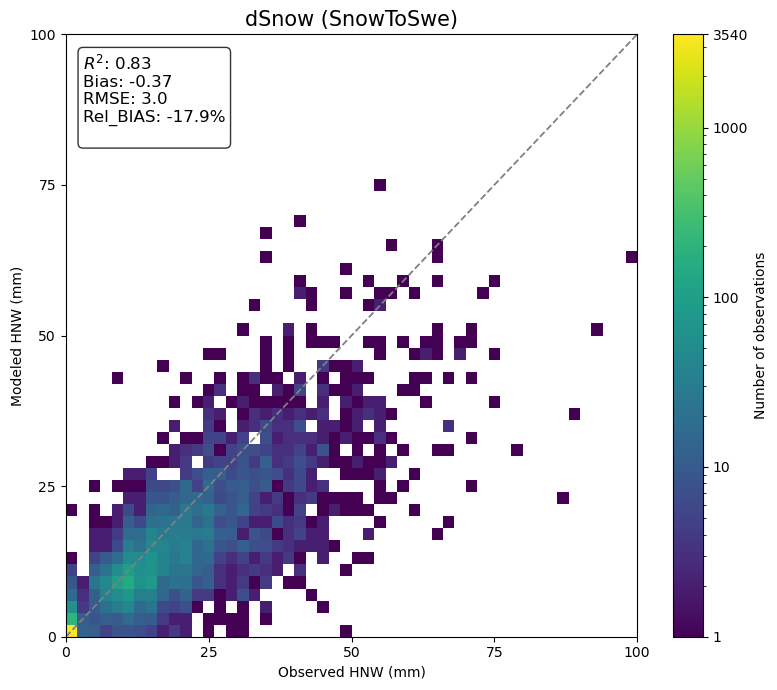

{'RMSE': np.float64(2.970141691081862),
 'Bias': np.float64(-0.3669064726101768),
 'Rel_BIAS': np.float64(-0.1792713024514109),
 'R2': np.float64(0.8277330572291213),
 'N': 35409}

In [4]:
val_helper.validate_hnw_mag25(
    HNW_val,
    full_season = False,
    model_name = "dSnow (SnowToSwe)",
    obs_col    = "HNW_obs",
    mod_col    = "HNW_mod",
    save_dir   = save_dir,
    filename   = f"SnowToSwe_hnw_validation_{calib_comment}.png",
)

## Validation — SWE (biweekly snow-course observations)

Density scatter of observed vs. modelled SWE, using the same filtered subset
as the HNW validation above (identical N).


Number of valid observations after filtering: 1054
{'RMSE': np.float64(32.759450353845736), 'Bias': np.float64(-5.744064118955523), 'Rel_BIAS': np.float64(-0.0289026485933518), 'R2': np.float64(0.9277242790477102), 'N': 1054}
Plot saved to: /Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/validation_plots/SnowToSwe_SWE_validation_SnowToSwe_default_Winkler2021.png


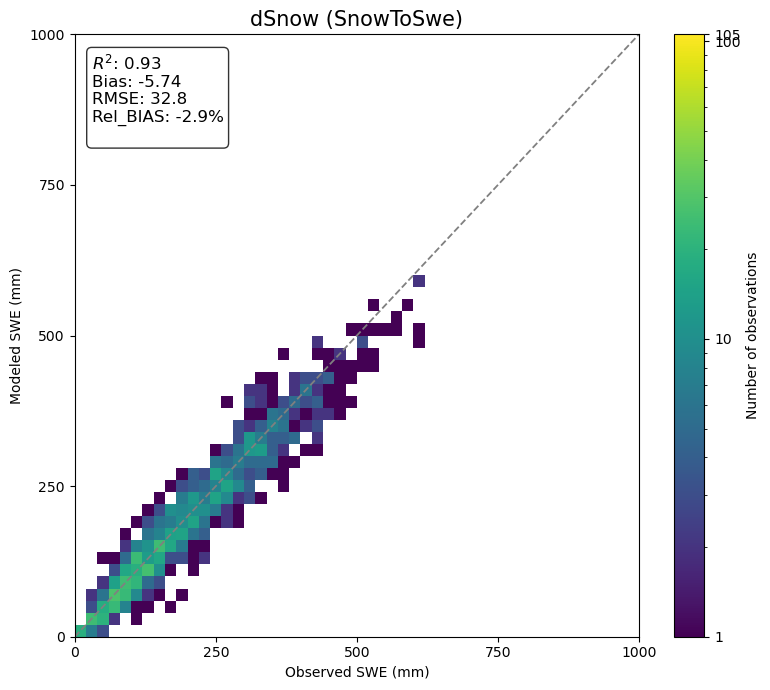

{'RMSE': np.float64(32.759450353845736),
 'Bias': np.float64(-5.744064118955523),
 'Rel_BIAS': np.float64(-0.0289026485933518),
 'R2': np.float64(0.9277242790477102),
 'N': 1054}

In [8]:
val_helper.validate_swe_mag25(
    SWE_val,
    full_season= True,
    model_name = "dSnow (SnowToSwe)",
    obs_col    = "SWE_obs",
    mod_col    = "SWE_mod",
    save_dir   = save_dir,
    filename   = f"SnowToSwe_SWE_validation_{calib_comment}.png",
)


In [ ]:
´´